# Per-Class Accuracy Analysis for EMG Air Drumming Model

This notebook loads the trained model and validation data to analyze performance per drum class.

In [31]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [32]:
# Load the model architecture (same as in model.py)
class EMGSpectroCNN(nn.Module):
    def __init__(self, num_classes, n_fft=128, hop_length=32):
        super(EMGSpectroCNN, self).__init__()
        import torchaudio.transforms as T
        
        self.spectrogram = T.Spectrogram(
            n_fft=n_fft, hop_length=hop_length, power=2.0
        )

        self.features = nn.Sequential(
            nn.Conv2d(in_channels=7, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout2d(0.2),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(0.2),
            nn.MaxPool2d(kernel_size=2),
        )

        self.fc_shared = nn.Sequential(nn.Linear(4096, 128), nn.ReLU(), nn.Dropout(0.5))
        self.head_drum = nn.Linear(128, num_classes)
        self.head_intensity = nn.Sequential(
            nn.Linear(128, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        spec = self.spectrogram(x)
        spec = torch.log1p(spec)
        x_feat = self.features(spec)
        x_flat = x_feat.view(x_feat.size(0), -1)
        shared_repr = self.fc_shared(x_flat)
        out_drum = self.head_drum(shared_repr)
        out_intensity = self.head_intensity(shared_repr).squeeze()
        return out_drum, out_intensity

In [33]:
# Load data and model
print("Loading data and model...")

# Load processed data
X_raw = np.load("data/X_data.npy")
y_drum_raw = np.load("data/y_drum.npy")
y_intensity_raw = np.load("data/y_intensity.npy")

# Load drum classes
drum_classes = np.load("data/drum_classes.npy", allow_pickle=True)
print(f"Drum classes: {drum_classes}")

Loading data and model...
Drum classes: ['Hi-Hat_BOTH' 'Hi-Hat_LEFT' 'Hi-Hat_RIGHT' 'Kick' 'Rest' 'Snare_BOTH'
 'Snare_LEFT' 'Snare_RIGHT']


In [34]:
# Load validation split (same as in training)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode drum labels to integers (same as training)
drum_encoder = LabelEncoder()
y_drum_encoded = drum_encoder.fit_transform(y_drum_raw)
print(f"Encoded drum labels: {drum_encoder.classes_}")

# Encode intensity to continuous floats (same as training)
intensity_map = {"Rest": 0.0, "Soft": 0.33, "Medium": 0.66, "Hard": 1.0}
y_intensity_encoded = np.array([intensity_map[val] for val in y_intensity_raw])

X_train, X_val, y_d_train, y_d_val, y_i_train, y_i_val = train_test_split(
    X_raw, y_drum_encoded, y_intensity_encoded, test_size=0.2, 
    stratify=y_drum_encoded, random_state=42
)

print(f"Validation set size: {X_val.shape[0]} samples")
print(f"Validation set shape: {X_val.shape}")
print(f"Intensity encoding: {intensity_map}")

Encoded drum labels: ['Hi-Hat_BOTH' 'Hi-Hat_LEFT' 'Hi-Hat_RIGHT' 'Kick' 'Rest' 'Snare_BOTH'
 'Snare_LEFT' 'Snare_RIGHT']
Validation set size: 132 samples
Validation set shape: (132, 500, 7)
Intensity encoding: {'Rest': 0.0, 'Soft': 0.33, 'Medium': 0.66, 'Hard': 1.0}


In [35]:
# Load trained model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

num_classes = len(drum_classes)
model = EMGSpectroCNN(num_classes=num_classes, n_fft=128, hop_length=32).to(device)
model.load_state_dict(torch.load("best_emg_air_drum_model.pth", weights_only=True))
model.eval()

print("Model loaded successfully!")

Using device: cuda
Model loaded successfully!


In [36]:
# Create validation dataset and dataloader
class EMGSpectrogramDataset(torch.utils.data.Dataset):
    def __init__(self, X, y_drum, y_intensity):
        self.X = torch.tensor(X, dtype=torch.float32).permute(0, 2, 1)
        self.y_drum = torch.tensor(y_drum, dtype=torch.long)
        self.y_intensity = torch.tensor(y_intensity, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y_drum[idx], self.y_intensity[idx]

val_dataset = EMGSpectrogramDataset(X_val, y_d_val, y_i_val)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [37]:
# Get predictions on validation set
print("Generating predictions...")

all_predictions = []
all_labels = []
all_intensities = []
all_intensity_preds = []

with torch.no_grad():
    for X_batch, y_drum_batch, y_int_batch in val_loader:
        X_batch = X_batch.to(device)
        
        pred_drum, pred_int = model(X_batch)
        pred_classes = torch.argmax(pred_drum, dim=1)
        
        all_predictions.extend(pred_classes.cpu().numpy())
        all_labels.extend(y_drum_batch.numpy())
        all_intensities.extend(y_int_batch.numpy())
        all_intensity_preds.extend(pred_int.cpu().numpy())

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)
all_intensities = np.array(all_intensities)
all_intensity_preds = np.array(all_intensity_preds)

print(f"Generated {len(all_predictions)} predictions")

Generating predictions...
Generated 132 predictions


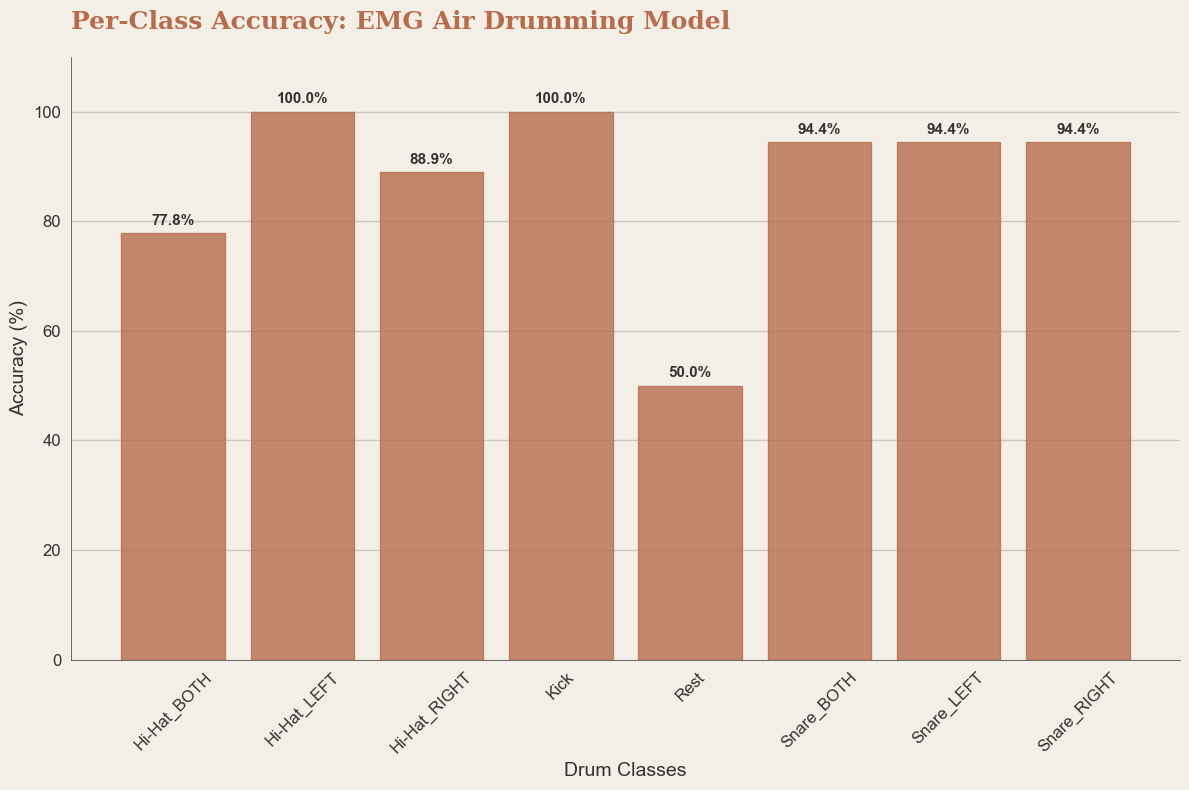

In [38]:
# Per-Class Accuracy Bar Plot with "The Muscular Musician" Theme
import matplotlib.pyplot as plt
import numpy as np

# Calculate per-class accuracy
from sklearn.metrics import accuracy_score
class_accuracies = {}
for i, class_name in enumerate(drum_encoder.classes_):
    class_mask = (all_labels == i)
    if class_mask.sum() > 0:
        class_acc = accuracy_score(all_labels[class_mask], all_predictions[class_mask]) * 100
        class_accuracies[class_name] = class_acc

# Set up the theme colors
BACKGROUND_COLOR = '#F4EFE6'  # Warm Cream / Soft Beige
ACCENT_COLOR = '#B66D4E'      # Terracotta / Rust Brown  
TEXT_COLOR = '#333333'         # Dark Charcoal / Soft Black

# Create the plot with theme styling
plt.figure(figsize=(12, 8), facecolor=BACKGROUND_COLOR)
ax = plt.gca()
ax.set_facecolor(BACKGROUND_COLOR)

# Create bar plot
classes = list(class_accuracies.keys())
accuracies = list(class_accuracies.values())
bars = ax.bar(classes, accuracies, color=ACCENT_COLOR, alpha=0.8, edgecolor=ACCENT_COLOR, linewidth=1)

# Styling according to theme
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(TEXT_COLOR)
ax.spines['bottom'].set_color(TEXT_COLOR)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# Labels and title with theme colors
ax.set_title('Per-Class Accuracy: EMG Air Drumming Model', 
             fontsize=18, fontweight='bold', color=ACCENT_COLOR, 
             fontfamily='serif', pad=20, loc='left')

ax.set_xlabel('Drum Classes', fontsize=14, color=TEXT_COLOR, fontfamily='sans-serif')
ax.set_ylabel('Accuracy (%)', fontsize=14, color=TEXT_COLOR, fontfamily='sans-serif')

# Tick styling
ax.tick_params(axis='x', colors=TEXT_COLOR, labelsize=12, rotation=45)
ax.tick_params(axis='y', colors=TEXT_COLOR, labelsize=12)

# Grid styling (subtle)
ax.yaxis.grid(True, alpha=0.2, color=TEXT_COLOR, linestyle='-')
ax.xaxis.grid(False)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{acc:.1f}%', ha='center', va='bottom', 
             fontsize=11, color=TEXT_COLOR, fontweight='bold',
             fontfamily='sans-serif')

# Set y-axis limits with padding
ax.set_ylim(0, max(accuracies) + 10)

# Add subtle border around plot
for spine in ax.spines.values():
    spine.set_edgecolor(TEXT_COLOR)
    spine.set_linewidth(0.5)

plt.tight_layout()
plt.show()

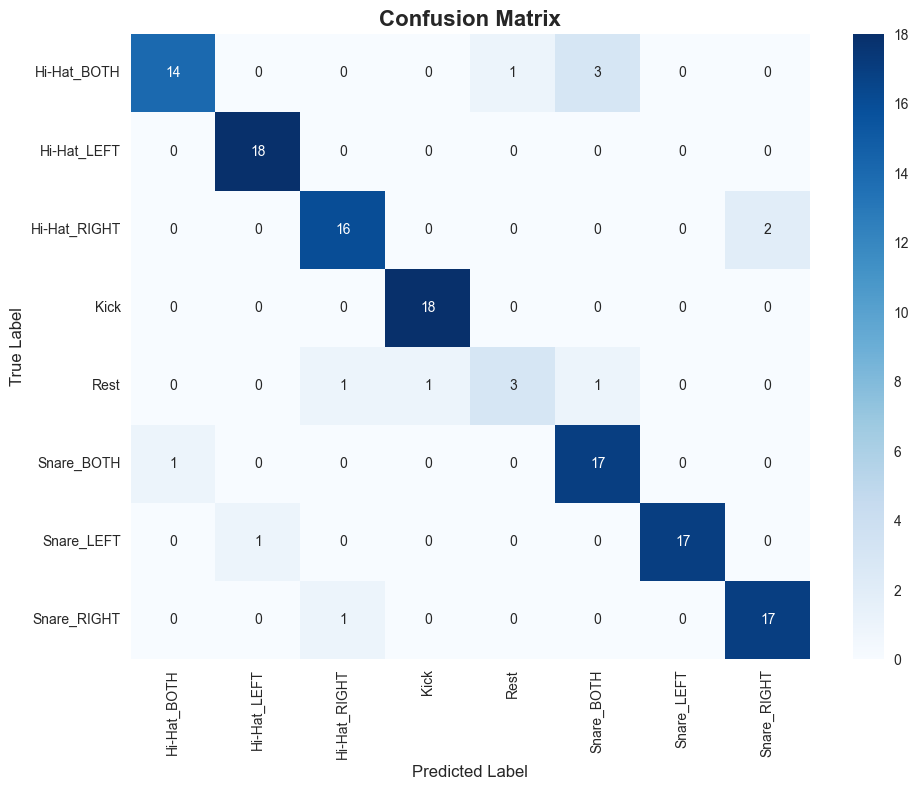

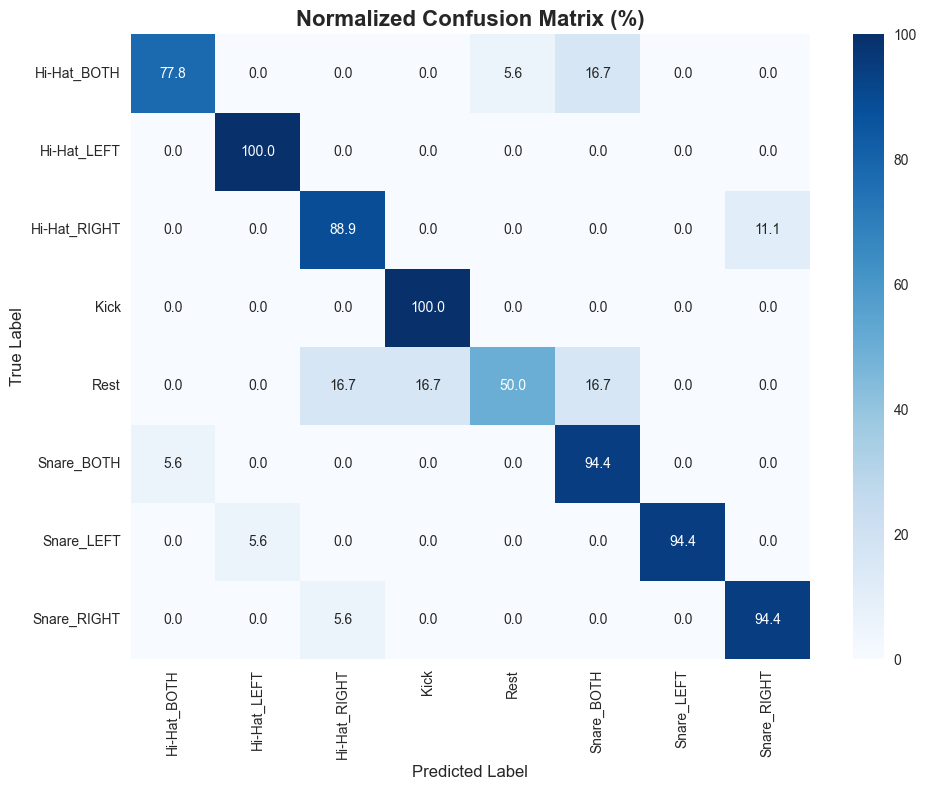

In [39]:
# Create Confusion Matrix
cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=drum_classes, yticklabels=drum_classes)
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

# Print normalized confusion matrix (percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.1f', cmap='Blues', 
            xticklabels=drum_classes, yticklabels=drum_classes)
plt.title('Normalized Confusion Matrix (%)', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

In [40]:
# Class-wise analysis with insights
print("\n" + "="*60)
print("DETAILED PER-CLASS ANALYSIS")
print("="*60)

overall_accuracy = accuracy_score(all_labels, all_predictions) * 100
print(f"\nOverall Model Accuracy: {overall_accuracy:.2f}%")
print(f"Total Validation Samples: {len(all_labels)}")

print("\n" + "-"*60)
print("PER-CLASS PERFORMANCE BREAKDOWN:")
print("-"*60)

for i, class_name in enumerate(drum_classes):
    accuracy = metrics_df.loc[class_name, 'recall'] * 100
    precision = metrics_df.loc[class_name, 'precision'] * 100
    f1 = metrics_df.loc[class_name, 'f1-score'] * 100
    support = metrics_df.loc[class_name, 'support']
    
    print(f"\n{class_name}:")
    print(f"  Accuracy: {accuracy:.1f}% ({int(support * accuracy/100)}/{int(support)} correct)")
    print(f"  Precision: {precision:.1f}%")
    print(f"  F1-Score: {f1:.1f}%")
    print(f"  Samples: {int(support)}")
    
    # Find most common misclassification
    class_cm_row = cm[i, :]
    class_cm_row[i] = 0  # Zero out correct predictions
    if class_cm_row.sum() > 0:
        most_confused_idx = np.argmax(class_cm_row)
        confusion_count = class_cm_row[most_confused_idx]
        confused_with = drum_classes[most_confused_idx]
        print(f"  Most confused with: {confused_with} ({confusion_count} times)")
    else:
        print(f"  No misclassifications!")


DETAILED PER-CLASS ANALYSIS

Overall Model Accuracy: 90.91%
Total Validation Samples: 132

------------------------------------------------------------
PER-CLASS PERFORMANCE BREAKDOWN:
------------------------------------------------------------

Hi-Hat_BOTH:
  Accuracy: 77.8% (14/18 correct)
  Precision: 93.3%
  F1-Score: 84.8%
  Samples: 18
  Most confused with: Snare_BOTH (3 times)

Hi-Hat_LEFT:
  Accuracy: 100.0% (18/18 correct)
  Precision: 94.7%
  F1-Score: 97.3%
  Samples: 18
  No misclassifications!

Hi-Hat_RIGHT:
  Accuracy: 88.9% (16/18 correct)
  Precision: 88.9%
  F1-Score: 88.9%
  Samples: 18
  Most confused with: Snare_RIGHT (2 times)

Kick:
  Accuracy: 100.0% (18/18 correct)
  Precision: 94.7%
  F1-Score: 97.3%
  Samples: 18
  No misclassifications!

Rest:
  Accuracy: 50.0% (3/6 correct)
  Precision: 75.0%
  F1-Score: 60.0%
  Samples: 6
  Most confused with: Hi-Hat_RIGHT (1 times)

Snare_BOTH:
  Accuracy: 94.4% (17/18 correct)
  Precision: 81.0%
  F1-Score: 87.2%
  Samp

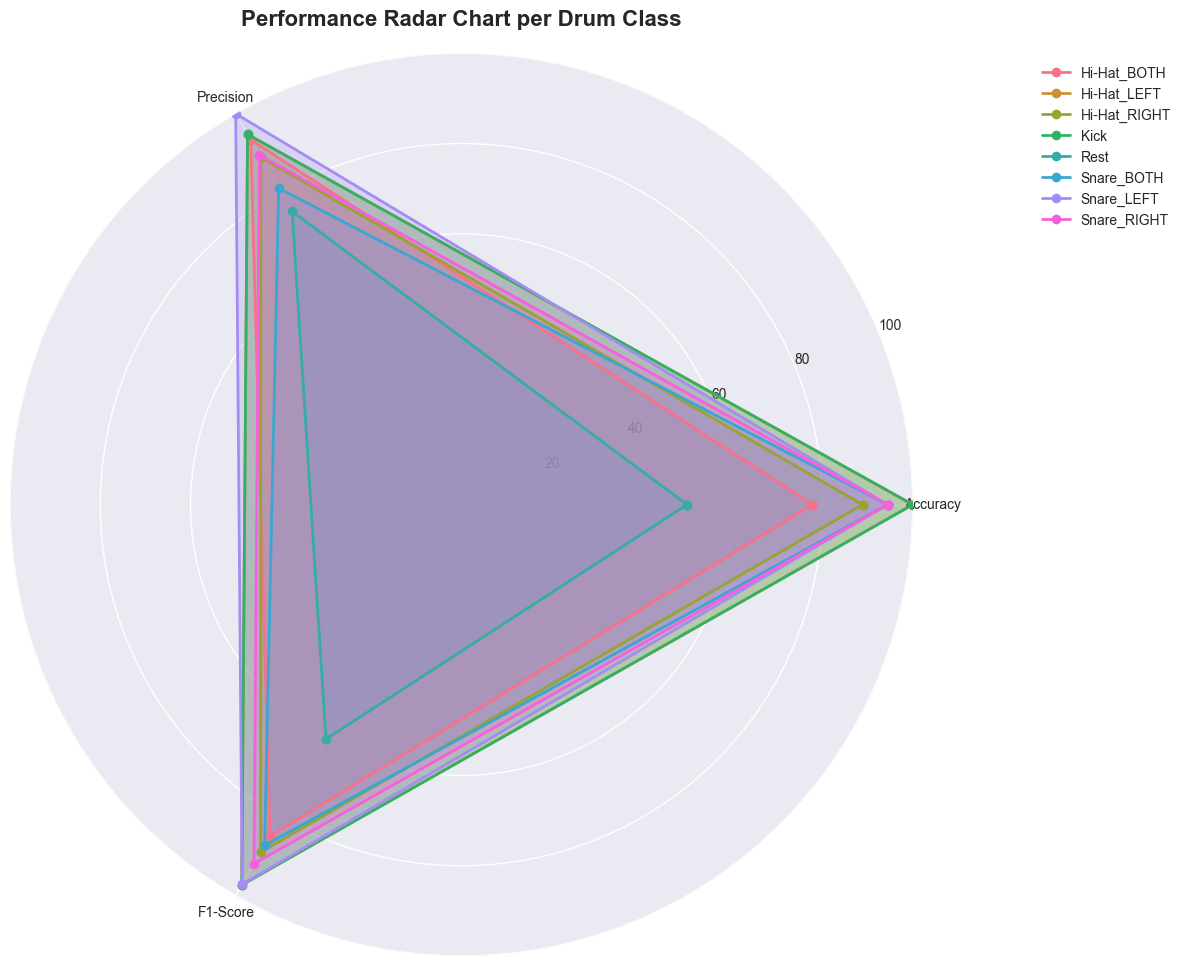

In [41]:
# Create a radar chart for comprehensive view
from math import pi

# Prepare data for radar chart
categories = ['Accuracy', 'Precision', 'F1-Score']
N = len(categories)

# Angles for each axis
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # Complete the loop

fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(projection='polar'))

# Plot each class
colors = sns.color_palette("husl", len(drum_classes))
for i, class_name in enumerate(drum_classes):
    values = [
        metrics_df.loc[class_name, 'recall'] * 100,
        metrics_df.loc[class_name, 'precision'] * 100,
        metrics_df.loc[class_name, 'f1-score'] * 100
    ]
    values += values[:1]  # Complete the loop
    
    ax.plot(angles, values, 'o-', linewidth=2, label=class_name, color=colors[i])
    ax.fill(angles, values, alpha=0.25, color=colors[i])

# Add labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_ylim(0, 100)
ax.set_title('Performance Radar Chart per Drum Class', size=16, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

plt.tight_layout()
plt.show()


INTENSITY PREDICTION ANALYSIS
Mean Squared Error (MSE): 0.0454
Mean Absolute Error (MAE): 0.1676
R² Score: 0.5030


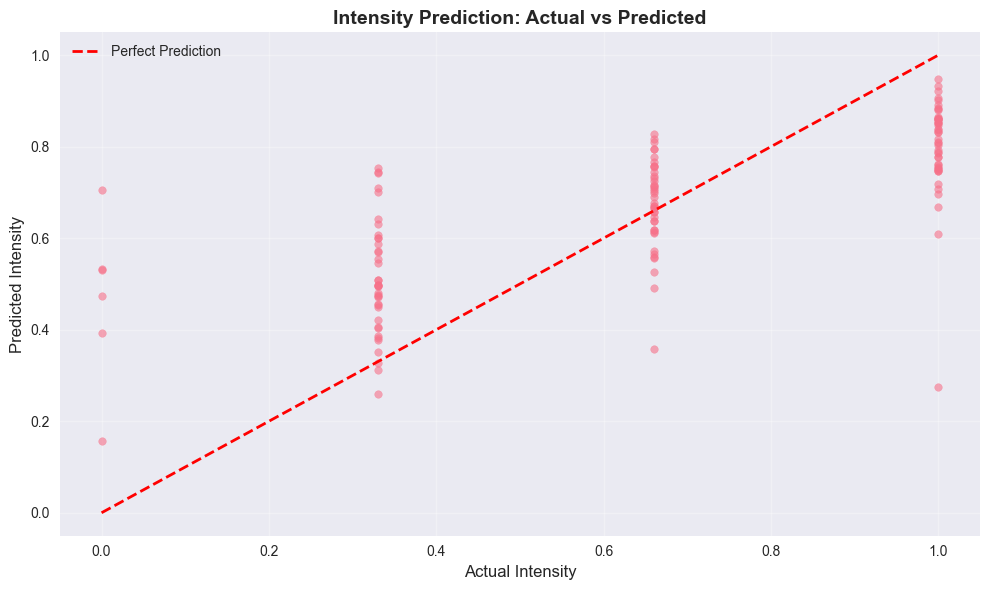

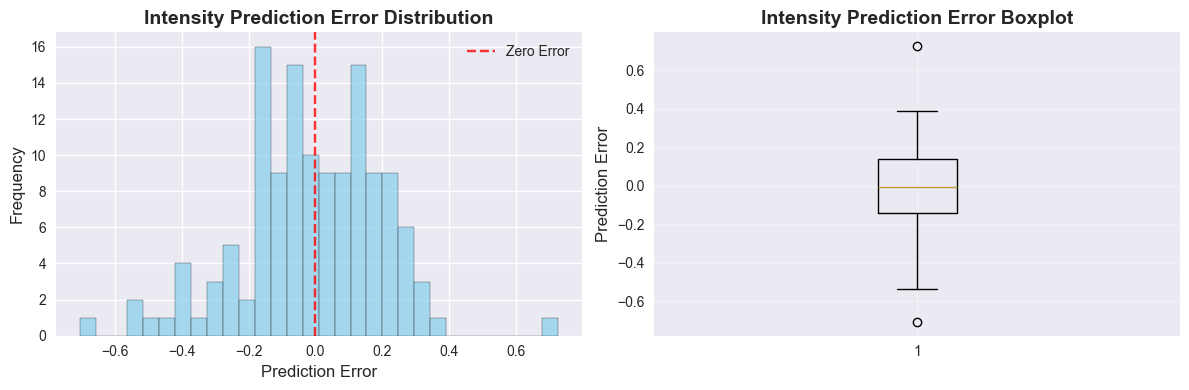

In [42]:
# Intensity prediction analysis (regression performance)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("\n" + "="*60)
print("INTENSITY PREDICTION ANALYSIS")
print("="*60)

mse = mean_squared_error(all_intensities, all_intensity_preds)
mae = mean_absolute_error(all_intensities, all_intensity_preds)
r2 = r2_score(all_intensities, all_intensity_preds)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")

# Plot intensity predictions vs actual
plt.figure(figsize=(10, 6))
plt.scatter(all_intensities, all_intensity_preds, alpha=0.6, s=30)
plt.plot([0, 1], [0, 1], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Intensity', fontsize=12)
plt.ylabel('Predicted Intensity', fontsize=12)
plt.title('Intensity Prediction: Actual vs Predicted', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Create intensity error distribution
intensity_errors = all_intensities - all_intensity_preds

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(intensity_errors, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.xlabel('Prediction Error', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Intensity Prediction Error Distribution', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.8, label='Zero Error')
plt.legend()

plt.subplot(1, 2, 2)
plt.boxplot(intensity_errors, vert=True)
plt.ylabel('Prediction Error', fontsize=12)
plt.title('Intensity Prediction Error Boxplot', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [43]:
# Summary and recommendations
print("\n" + "="*80)
print("SUMMARY AND RECOMMENDATIONS")
print("="*80)

# Find best and worst performing classes
best_class = metrics_df['recall'].idxmax()
worst_class = metrics_df['recall'].idxmin()
best_accuracy = metrics_df.loc[best_class, 'recall'] * 100
worst_accuracy = metrics_df.loc[worst_class, 'recall'] * 100

print(f"\nBest performing class: {best_class} ({best_accuracy:.1f}% accuracy)")
print(f"Worst performing class: {worst_class} ({worst_accuracy:.1f}% accuracy)")

# Classes with low sample count
low_sample_classes = metrics_df[metrics_df['support'] < 20].index.tolist()
if low_sample_classes:
    print(f"\nClasses with low sample count (<20 samples): {low_sample_classes}")
    print("Recommendation: Collect more training data for these classes")

# Classes with high confusion
print("\n" + "-"*40)
print("HIGH CONFUSION PAIRS:")
print("-"*40)

for i in range(len(drum_classes)):
    for j in range(len(drum_classes)):
        if i != j and cm[i, j] > 0:
            confusion_rate = cm[i, j] / cm[i, :].sum() * 100
            if confusion_rate > 10:  # More than 10% confusion
                print(f"{drum_classes[i]} confused with {drum_classes[j]}: {confusion_rate:.1f}% ({cm[i, j]} cases)")

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)


SUMMARY AND RECOMMENDATIONS

Best performing class: Hi-Hat_LEFT (100.0% accuracy)
Worst performing class: Rest (50.0% accuracy)

Classes with low sample count (<20 samples): [np.str_('Hi-Hat_BOTH'), np.str_('Hi-Hat_LEFT'), np.str_('Hi-Hat_RIGHT'), np.str_('Kick'), np.str_('Rest'), np.str_('Snare_BOTH'), np.str_('Snare_LEFT'), np.str_('Snare_RIGHT')]
Recommendation: Collect more training data for these classes

----------------------------------------
HIGH CONFUSION PAIRS:
----------------------------------------
Hi-Hat_BOTH confused with Rest: 25.0% (1 cases)
Hi-Hat_BOTH confused with Snare_BOTH: 75.0% (3 cases)
Hi-Hat_RIGHT confused with Snare_RIGHT: 100.0% (2 cases)
Rest confused with Hi-Hat_RIGHT: 33.3% (1 cases)
Rest confused with Kick: 33.3% (1 cases)
Rest confused with Snare_BOTH: 33.3% (1 cases)
Snare_BOTH confused with Hi-Hat_BOTH: 100.0% (1 cases)
Snare_LEFT confused with Hi-Hat_LEFT: 100.0% (1 cases)
Snare_RIGHT confused with Hi-Hat_RIGHT: 100.0% (1 cases)

ANALYSIS COMPLETE